In [595]:
import sklearn
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import numpy as np  # package for arrays
import matplotlib.pyplot as plt  # package for plotting
from time import time 
import random as ran

In [596]:
'''
So far only the data in:

data/method_1/#1_X.txt

has worked
'''

'\nSo far only the data in:\n\ndata/method_1/#1_X.txt\n\nhas worked\n'

In [597]:
def get_details(y):
    temps = set(y)
    temps = np.sort(np.array(list(temps)))
    np.sort([1,])
    Tcount = {}
    for kT in temps:
        Tcount[kT] = np.count_nonzero(y==kT)
    return Tcount

def order_data(y, X):
    indices = np.argsort(y)
    y = y[indices]
    X = X[indices]
    return (y, X)

def reconstruct_lattice(lattice):
    L = round(np.sqrt(len(lattice)))
    return np.reshape(lattice, (L,L))

def show_state(state):
    img = reconstruct_lattice(state)
    _, ax = plt.subplots()
    ax.imshow(img, cmap=plt.get_cmap('gray'), interpolation="nearest")

### Data

In [598]:
# path = 'data/method_1/#1'
path = 'data/up_down/L=40_x=0.9'

X = np.loadtxt(path+'_X.txt') 
y = np.loadtxt(path+'_y.txt') 

y, X = order_data(y, X)

get_details(y)

{1.1: 38,
 1.2: 37,
 1.3: 36,
 1.4: 38,
 1.5: 36,
 1.6: 36,
 1.7: 36,
 1.8: 48,
 1.9: 45,
 2.0: 43,
 2.1: 42,
 2.2: 33,
 2.3: 36,
 2.4: 39,
 2.5: 38,
 2.6: 45,
 2.7: 44}

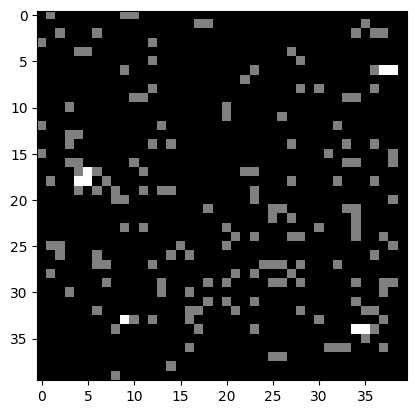

In [599]:
show_state(X[0])

### Mean absolute value + error bars

In [600]:
def mean_absolute(y, values, central_limit=True):
    temperatures = list(set(y))
    
    means = []
    errs = []
    for kT in temperatures:
        filt = y==kT
        samples = values[filt]
        N_samples = len(samples)
        
        samples = np.abs(samples)
        mean = np.mean(samples)
        if central_limit:
            err = np.std(samples)/np.sqrt(N_samples)
        else:
            err = np.std(samples)
        
        errs.append(err)
        means.append(mean)
        
    return temperatures, means, errs
    
def reorder(temperatures, values, errs='None'):
    temperatures = np.array(temperatures)
    values = np.array(values)
    errs = np.array(errs)
    
    indices = np.argsort(temperatures)
    
    if errs != 'None':
        return temperatures[indices], values[indices], errs[indices]
    
    return temperatures[indices], values[indices]

### Magnetisation


In [601]:
def magnetisation(state):
    N = np.count_nonzero(state)
    return np.sum(state)/N

def mags(states):
    m = []
    for state in states:
        m.append(magnetisation(state))
    return np.array(m)

def plot_m(X, y):
    m = mags(X)
    T, M, err = mean_absolute(y, m, central_limit=True)
    T, M, err = reorder(T, M, err)
    
    plt.errorbar(T, M, yerr=err, fmt='.', ecolor='red')

/var/folders/v_/fs61ry8x6h9dg62cykggbxh00000gn/T/ipykernel_49579/842564004.py:30: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if errs != 'None':


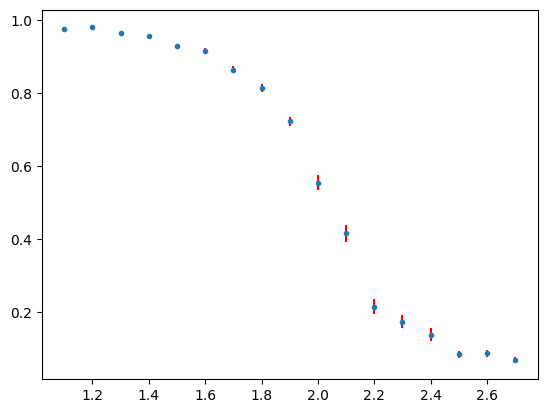

In [602]:
plot_m(X, y)

### Specific Heat (it is NOT the same as magnetic susceptibility)

$$ C_v = \sigma_E^2/T^2 $$

where $\sigma_E$ is the std of the energy

Note: we are setting k=1 and J=1

In [603]:
def energy(state):
    # reconstruct shape
    N = len(state)
    L = round(np.sqrt(N))
    state = np.reshape(state, (L,L))
    
    J = 1 # this is what it is for everything
    
    E = 0
    for i,row in enumerate(state):
        for j,spin in enumerate(row):
            
            
            NNa = state[(i-1, j)] # Nearest neighbor above
            NNl = state[(i, j-1)] # Nearest neighbor left
            if i == L-1:
                NNb = state[(0, j)]
            else:
                NNb = state[(i+1, j)]
            if j == L-1:
                NNr = state[(i, 0)]
            else:
                NNr = state[(i, j+1)]
            
            E -= J*spin*(NNb + NNa + NNl + NNr)
    
    return E/2 # we counted each connection twice so we need to divide the energy by 2

def energies(X):
    H = []
    for state in X:
        H.append(energy(state))
    return np.array(H)

def specific_heat(y, energies):
    temperatures = list(set(y))
    
    Cv = []
    for T in temperatures:
        filt = y==T
        energies_ = energies[filt]
        sigma = np.std(energies_)
        Cv.append((sigma/T)**2)
        
    return Cv

def plot_Cv(y, X):
    H = energies(X)
    Cv = specific_heat(y, H)
    T = list(set(y))
    
    plt.scatter(T, Cv)

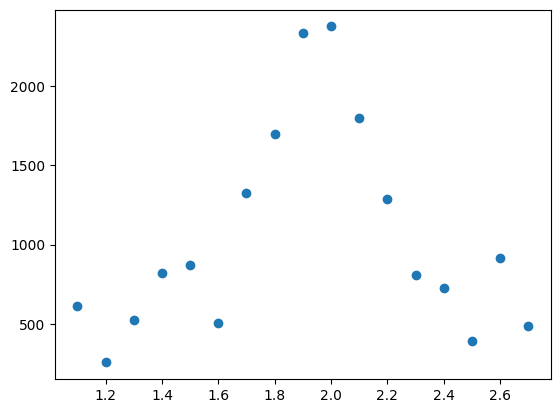

In [604]:
plot_Cv(y, X)

### Binder ratios

$$ Q = \frac{<m^2>}{<|m|>^2} $$

In [605]:
def binder(values, y, p=1):
    temperatures = list(set(y))
    squares = values**(2*p)
    absolutes = np.abs(values)**p # aboslutes to the power of p
    
    Q = []
    for kT in temperatures:
        filt = y==kT
        squares_ = squares[filt]
        absolutes_ = absolutes[filt]
        
        q = np.mean(squares_)/(np.mean(absolutes_)**2)
        Q.append(q)
    
    return Q 

def plot_binder(y, X):
    T = list(set(y))
    m = mags(X)
    Q = binder(m, y)
    T, Q = reorder(T, Q)
    plt.plot(T, Q)

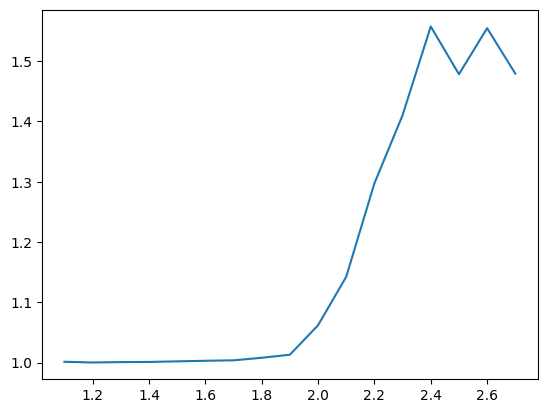

In [606]:
plot_binder(y, X)

# PCA

In [607]:
t1 = time()
reduced_data = PCA(n_components=2).fit_transform(X)
print(time()-t1)
reduced_data.shape

0.04656219482421875


(670, 2)

In [608]:
p1 = reduced_data[:, 0]
p2 = reduced_data[:, 1]

### Analogy to magnetisation and magnetic susceptibility

In [609]:
temperatures, p1_mean, err1 = mean_absolute(y, p1)
temperatures, p2_mean, err2 = mean_absolute(y, p2)

Text(0.5, 1.0, '<|p2|> vs T')

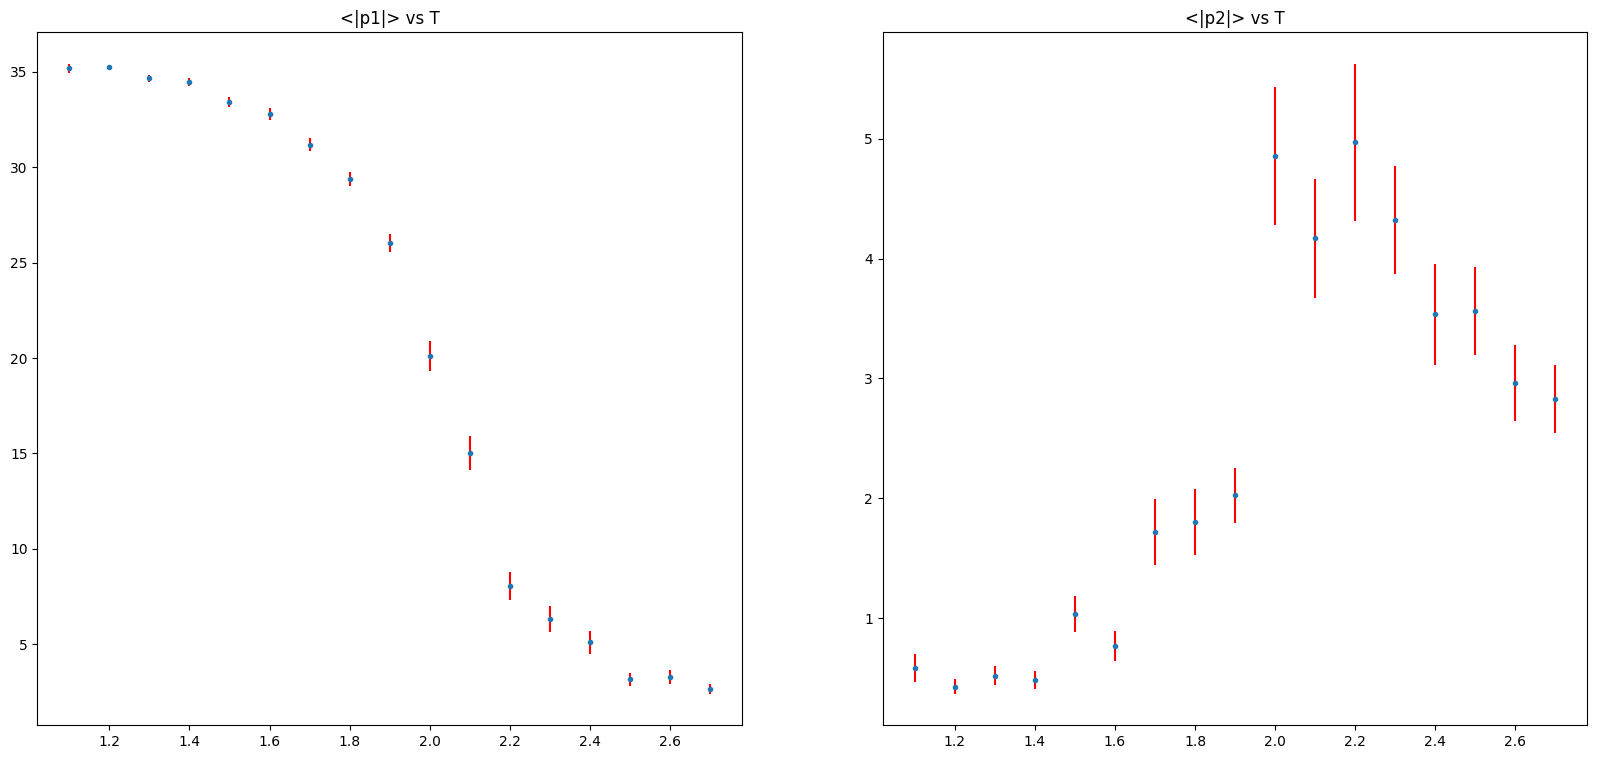

In [610]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,9))

# axs[0].scatter(temperatures, p1_mean)
axs[0].errorbar(temperatures, p1_mean, yerr=err1, fmt='.', ecolor='red')
axs[0].set_title('<|p1|> vs T')

axs[1].errorbar(temperatures, p2_mean, yerr=err2, fmt='.', ecolor='red')
axs[1].set_title('<|p2|> vs T')


Text(0.5, 0, 'p1')

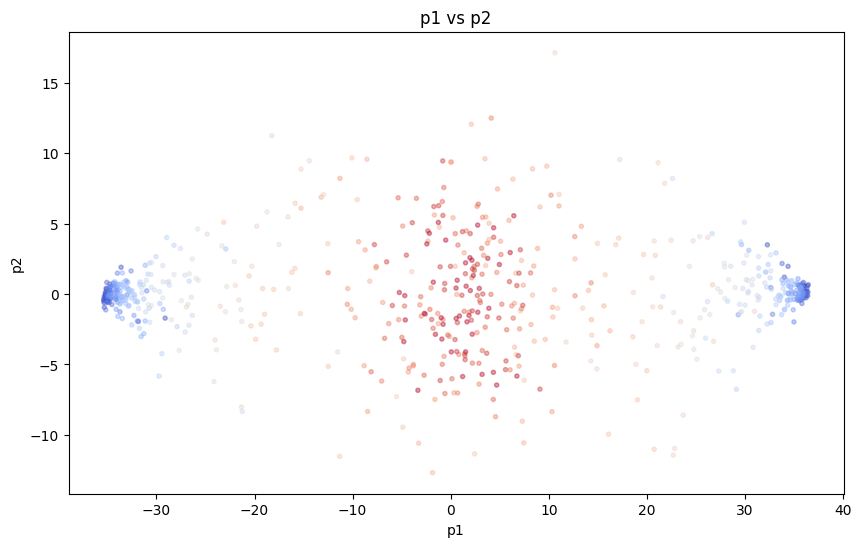

In [611]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(p1, p2, c=y, cmap='coolwarm', alpha=0.4, marker='.')
ax.set_title('p1 vs p2')
ax.set_ylabel('p2')
ax.set_xlabel('p1')

# fig.colorbar(cm.ScalarMappable(norm=None, cmap='coolwarm'), ax=ax)

## Plots of above and below Tc

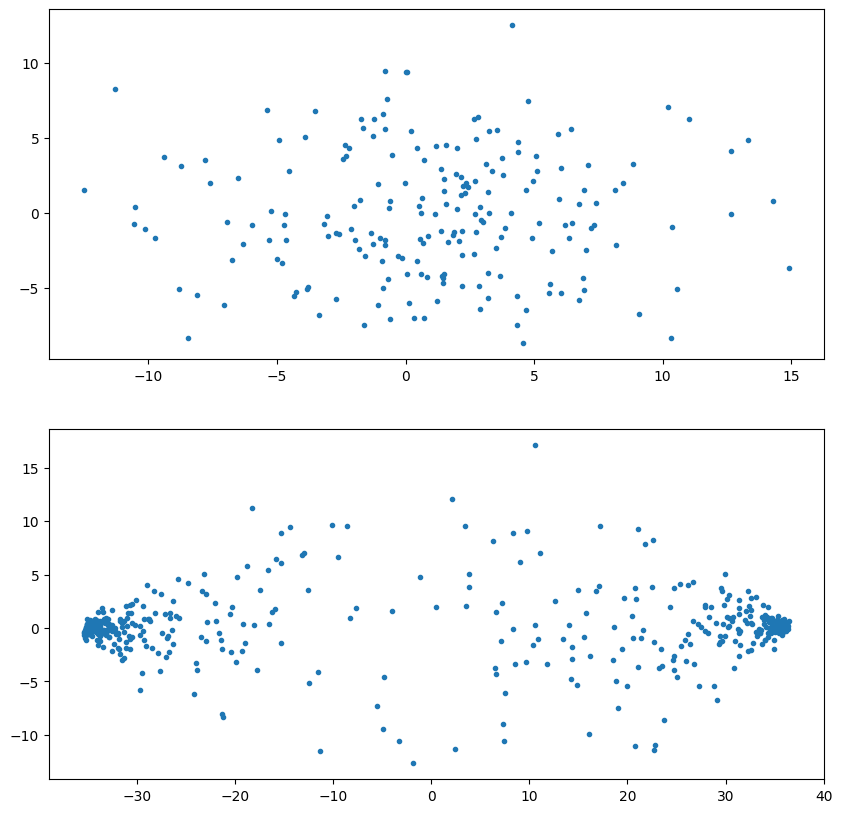

In [612]:
Tc = 2.2691
above = (y>2.2691)
below = (y<2.2691)


fig, axs = plt.subplots(nrows = 2, figsize=(10, 10))

axs[0].scatter(p1[above], p2[above], alpha=1, marker='.')
axs[1].scatter(p1[below], p2[below], alpha=1, marker='.')

## Plotting every temperature

### Clustering with KMeans

In [534]:
kmeans = KMeans(init="k-means++", n_clusters=3, n_init=4)
kmeans.fit(reduced_data)

KMeans(n_clusters=3, n_init=4)

Text(0.5, 0, 'p1')

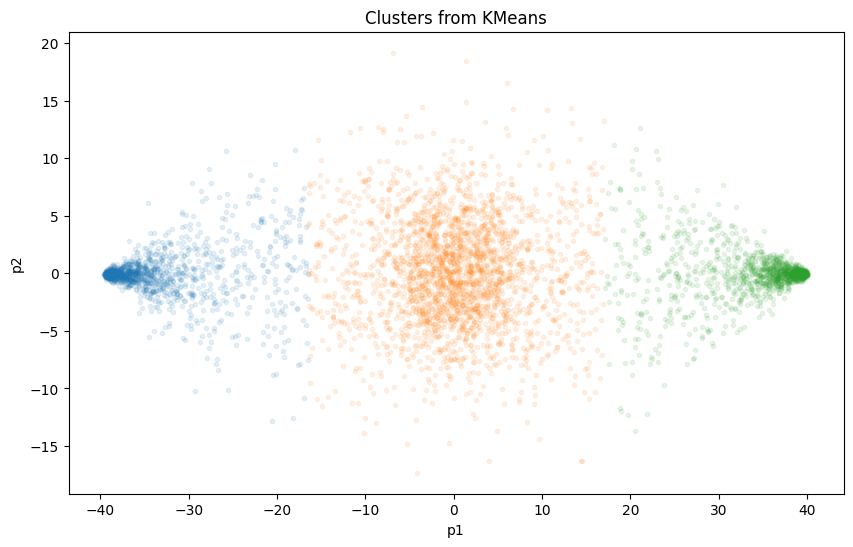

In [535]:
fig, ax = plt.subplots(figsize=(10, 6))

cluster0 = reduced_data[kmeans.labels_ == 0]
cluster1 = reduced_data[kmeans.labels_ == 1]
cluster2 = reduced_data[kmeans.labels_ == 2]

ax.scatter(cluster0[:, 0], cluster0[:, 1], alpha=0.1, marker='.')
ax.scatter(cluster1[:, 0], cluster1[:, 1], alpha=0.1, marker='.')
ax.scatter(cluster2[:, 0], cluster2[:, 1], alpha=0.1, marker='.')

ax.set_title('Clusters from KMeans')
ax.set_ylabel('p2')
ax.set_xlabel('p1')

### Tc from clustered temperatures 

###### Alg 1: ignore distance to centroid

In [547]:
labels = kmeans.labels_
y = y # should already be in order ascending order
n = len(y)

index = 4000
n_ordered_below = np.count_nonzero(labels[:index])
n_disordered_below = 
n_disordered = len(y) - n_ordered
print(y[index])
print(n_ordered)
print(n_disordered)

2.8
2714
2206


### DBSCAN for bad data (method_2 data)